<div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Automate The Boring Stuff With LLMs</h1>
<h1>Agents: Privacy-Policy Compliance Crew (CrewAI)</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import os
import json
import warnings
import re
warnings.filterwarnings('ignore')

from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
tqdm.pandas()

from typing import List
from pydantic import BaseModel, Field
import asyncio
import time

from crewai import Agent, Task, Crew, Process, LLM
from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Markdown, display

import requests

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: a6a5b1aea38d59c8551e92965f8085d3a45310e6

IPython            : 9.13.0
crewai             : 1.6.1
json               : 2.0.9
langchain_anthropic: 1.4.2
langchain_core     : 1.4.9
langgraph          : 1.2.8
matplotlib         : 3.10.9
numpy              : 2.4.4
pandas             : 3.0.2
pydantic           : 2.13.3
re                 : 2.2.1
requests           : 2.33.1
tqdm               : 4.67.3
watermark          : 2.6.0



Load default figure style

In [3]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Setup

In [4]:
claude_llm = LLM(model='anthropic/claude-opus-4-5', temperature=0)

# Source documents

Privacy policies are public; we fetch a few and trim them to a manageable size. If a fetch fails, fall back to a tiny example so the notebook still runs end-to-end.

In [5]:
POLICY_URLS = {
    'github': 'https://docs.github.com/en/site-policy/privacy-policies/github-general-privacy-statement',
    'duckduckgo': 'https://duckduckgo.com/privacy',
    'wikipedia': 'https://foundation.wikimedia.org/wiki/Policy:Privacy_policy',
}

FALLBACK = (
    'We collect your name and email when you sign up. We use cookies to remember '
    'your preferences. We share aggregated, non-identifying usage data with our '
    'analytics provider. You can request deletion of your account at any time by '
    'emailing privacy@example.com. We retain logs for 90 days.'
)

def fetch_policy(url: str, max_chars: int = 12000) -> str:
    try:
        r = requests.get(url, timeout=10,
                          headers={'User-Agent': 'd4sci-webinar/1.0'})
        text = re.sub(r'<[^>]+>', ' ', r.text) if '<' in r.text else r.text
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:max_chars]
    except Exception:
        return FALLBACK

policies = {name: fetch_policy(url) for name, url in POLICY_URLS.items()}

for k, v in policies.items():
    print(f'{k:12s} {len(v):6d} chars')

github        12000 chars
duckduckgo    12000 chars
wikipedia     12000 chars


# Compliance checklist

Distilled from GDPR (Articles 5, 13–22, 32) and CCPA. Real audits use 100+ items; we keep 8 to make the demo fast while still showing the pattern.

In [6]:
CHECKLIST = [
    ('purpose_limitation', 'States specific purposes for which data is processed (GDPR Art. 5(1)(b))'),
    ('data_minimization', 'Limits collection to what is necessary (GDPR Art. 5(1)(c))'),
    ('retention_period', 'Specifies how long data is kept (GDPR Art. 5(1)(e))'),
    ('third_party_sharing', 'Discloses third parties data is shared with (GDPR Art. 13)'),
    ('user_rights', 'Mentions access, rectification, deletion, portability rights (GDPR Art. 15-20)'),
    ('contact_dpo', 'Provides a privacy/DPO contact channel (GDPR Art. 13(1)(b))'),
    ('legal_basis', 'States legal basis for processing (GDPR Art. 6)'),
    ('ccpa_opt_out', 'Mentions Do Not Sell / opt-out for California users (CCPA)'),
]
checklist_md = '\n'.join(f'- **{k}** — {v}' for k, v in CHECKLIST)
print(checklist_md)

- **purpose_limitation** — States specific purposes for which data is processed (GDPR Art. 5(1)(b))
- **data_minimization** — Limits collection to what is necessary (GDPR Art. 5(1)(c))
- **retention_period** — Specifies how long data is kept (GDPR Art. 5(1)(e))
- **third_party_sharing** — Discloses third parties data is shared with (GDPR Art. 13)
- **user_rights** — Mentions access, rectification, deletion, portability rights (GDPR Art. 15-20)
- **contact_dpo** — Provides a privacy/DPO contact channel (GDPR Art. 13(1)(b))
- **legal_basis** — States legal basis for processing (GDPR Art. 6)
- **ccpa_opt_out** — Mentions Do Not Sell / opt-out for California users (CCPA)


# 5. Define the agents

Three rules of thumb when designing a crew:
1. **One responsibility per agent.** "Researcher" extracts facts; "Officer" judges them.
2. **Explicit goals.** The `goal` field steers behaviour more than a long backstory.
3. **Constrain output format in the *task*, not the agent** — keeps agents reusable.

In [7]:
researcher = Agent(
    role='Privacy Researcher',
    goal='Extract every concrete factual statement about how data is collected, '
         'used, shared, retained, or protected in the given privacy policy.',
    backstory='You are a meticulous analyst who quotes the source. You never infer.',
    llm=claude_llm,
    verbose=False,
)

officer = Agent(
    role='Compliance Officer',
    goal='Map extracted statements to a GDPR/CCPA checklist and identify which '
         'items are covered, partially covered, or missing.',
    backstory='You are a privacy-program lead. You cite checklist items by id.',
    llm=claude_llm,
    verbose=False,
)

writer = Agent(
    role='Audit Writer',
    goal='Compose a one-page executive audit report with a verdict, top three '
         'gaps, and prioritised remediation steps.',
    backstory='You write for a CEO who has 90 seconds.',
    llm=claude_llm,
    verbose=False,
)

# 6. Tasks (sequential pipeline)

CrewAI tasks default to passing the previous task's output forward, so the researcher's facts arrive in the officer's context, and so on.

In [8]:
def build_tasks(policy_text: str):
    t1 = Task(
        description=(
            'Read the policy below and produce a numbered list of factual statements. '
            'Each item: a 1-sentence paraphrase + a short verbatim quote in <quote>...</quote>.\n\n'
            f'POLICY:\n{policy_text}'
        ),
        expected_output='Numbered list, ~10-20 items.',
        agent=researcher,
    )
    t2 = Task(
        description=(
            'Using the extracted facts and the checklist below, produce a JSON object '
            'mapping each checklist id to {status: covered|partial|missing, evidence: str}.\n\n'
            f'CHECKLIST:\n{checklist_md}'
        ),
        expected_output='Pure JSON object — no prose around it.',
        agent=officer,
        context=[t1],
    )
    t3 = Task(
        description=(
            'Write a 250-word executive audit report. Include: overall verdict '
            '(compliant/partial/non-compliant), top 3 gaps with checklist ids, '
            '3 prioritised remediation steps. Markdown only.'
        ),
        expected_output='Markdown report, ~250 words.',
        agent=writer,
        context=[t1, t2],
    )
    return [t1, t2, t3]

# 7. Synchronous run — one policy at a time

Time it. We'll compare against the async version below.

In [9]:
def audit_sync(name, text):
    crew = Crew(agents=[researcher, officer, writer],
                tasks=build_tasks(text),
                process=Process.sequential, 
                verbose=False)
    return crew.kickoff()

t0 = time.time()
sync_results = {}
for name, text in tqdm(policies.items(), desc='Sync audits'):
    sync_results[name] = str(audit_sync(name, text))
sync_seconds = time.time() - t0
print(f'\nSync total: {sync_seconds:.1f}s')

Sync audits:   0%|          | 0/3 [00:00<?, ?it/s]


Sync total: 92.5s


Show one report

In [10]:
first = next(iter(sync_results))
print(f'=== {first} ===')
display(Markdown(sync_results[first]))

=== github ===


# Executive Privacy Audit Report: GitHub Privacy Statement

**Date:** Audit Period 2024  
**Subject:** GDPR & CCPA Compliance Assessment  
**Classification:** Confidential

---

## Overall Verdict: **PARTIAL COMPLIANCE**

GitHub's Privacy Statement demonstrates foundational privacy practices but contains significant gaps requiring immediate attention to achieve full regulatory compliance.

---

## Top 3 Compliance Gaps

| Priority | Gap | Checklist ID | Risk Level |
|----------|-----|--------------|------------|
| 1 | **No retention periods disclosed** | `retention_period` | High |
| 2 | **User rights not documented** | `user_rights` | High |
| 3 | **CCPA opt-out mechanism absent** | `ccpa_opt_out` | Medium |

### Gap Details

1. **Retention Period (Missing):** No information exists regarding data retention timelines, violating GDPR Article 13(2)(a) transparency requirements.

2. **User Rights (Missing):** The statement fails to inform users of access, rectification, deletion, or portability rights—core GDPR Articles 15-20 obligations.

3. **CCPA Opt-Out (Missing):** No "Do Not Sell My Personal Information" mechanism or disclosure exists for California consumers, creating CCPA §1798.120 exposure.

---

## Prioritised Remediation Steps

| Step | Action | Owner | Timeline |
|------|--------|-------|----------|
| **1** | Draft and publish data retention schedule with specific timeframes per data category | Legal/Privacy | 30 days |
| **2** | Add comprehensive user rights section detailing access, correction, deletion, and portability procedures with contact methods | Privacy Team | 45 days |
| **3** | Implement CCPA-compliant opt-out link and update statement with California-specific disclosures | Engineering/Legal | 60 days |

---

## Strengths Noted
- Clear purpose limitation disclosures
- Transparent third-party sharing practices
- Consent mechanisms for non-essential cookies in applicable jurisdictions

---

**Prepared by:** Audit Writer  
**Next Review:** Q1 2025

# 8. Asynchronous run — all policies in parallel

Each policy is independent, so we wrap the sync function in a thread pool. (CrewAI also has native `kickoff_async` per crew; using `asyncio.to_thread` keeps this notebook portable across crewai versions.)

In [11]:
async def audit_all_async(items):
    async def one(name, text):
        return name, await asyncio.to_thread(audit_sync, name, text)
    return dict(await asyncio.gather(*[one(n, t) for n, t in items.items()]))

t0 = time.time()
async_results = await audit_all_async(policies)
async_seconds = time.time() - t0
print(f'Async total: {async_seconds:.1f}s')
print(f'Speed-up: {sync_seconds / async_seconds:.2f}x')

Async total: 35.5s
Speed-up: 2.60x


# 9. Speed comparison plot

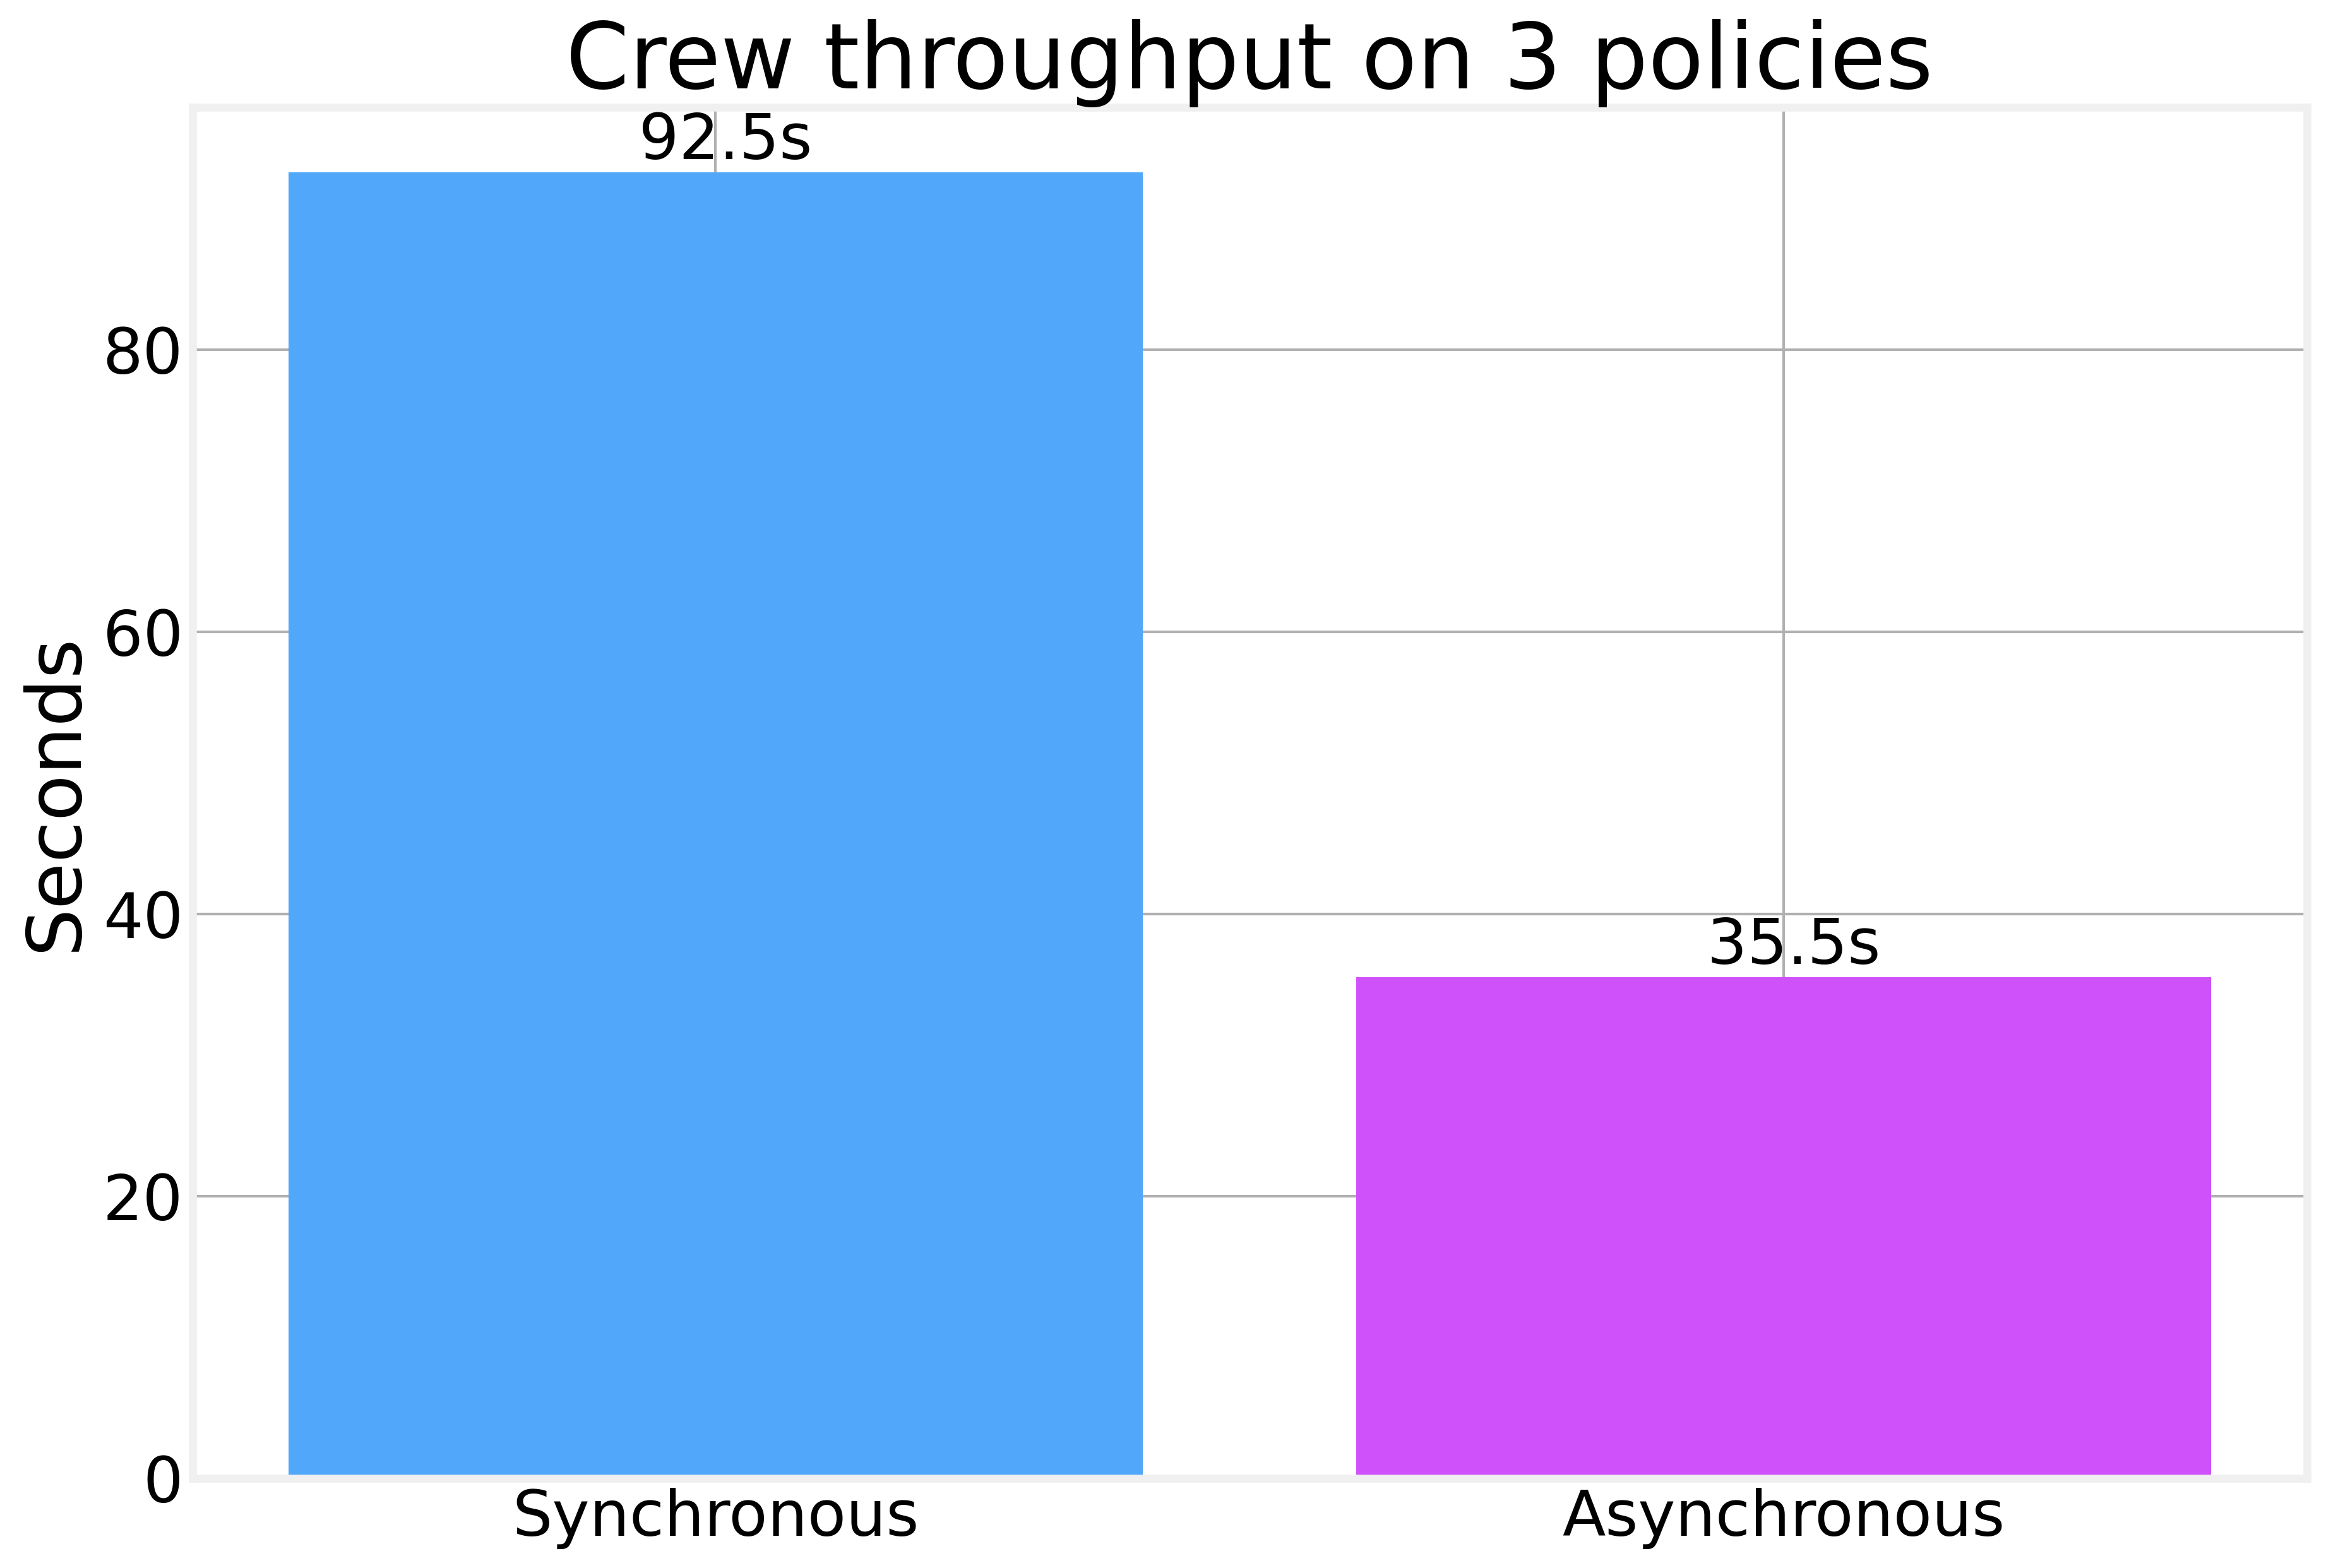

In [12]:
fig, ax = plt.subplots()
ax.bar(['Synchronous', 'Asynchronous'],
       [sync_seconds, async_seconds],
       color=[colors[0], colors[1]])
ax.set_ylabel('Seconds')
ax.set_title(f'Crew throughput on {len(policies)} policies')
for i, v in enumerate([sync_seconds, async_seconds]):
    ax.text(i, v, f' {v:.1f}s', va='bottom', ha='center')

# 10. Generated checklist artefact

Save the per-policy compliance JSON for downstream tooling (a dashboard, an issue tracker, etc.). In a real system this is the hand-off into a Jira / Linear pipeline.

In [13]:
out_path = 'data/compliance_audits.json'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, 'w') as f:
    json.dump({k: str(v) for k, v in async_results.items()}, f, indent=2)
print('Wrote', out_path)

Wrote data/compliance_audits.json


In [14]:
!cat data/compliance_audits.json

{
  "github": "# Executive Audit Report: GitHub Privacy Statement\n\n**Date:** Audit Period 2024  \n**Subject:** GDPR/CCPA Compliance Assessment  \n**Classification:** Confidential\n\n---\n\n## Overall Verdict: **PARTIAL COMPLIANCE**\n\nGitHub's Privacy Statement demonstrates foundational transparency regarding data collection and processing purposes but exhibits significant gaps in critical compliance areas that require immediate attention.\n\n---\n\n## Top 3 Compliance Gaps\n\n| Priority | Gap | Checklist ID | Risk Level |\n|----------|-----|--------------|------------|\n| 1 | **User Rights Disclosure Missing** | `user_rights` | High |\n| 2 | **Data Retention Period Undefined** | `retention_period` | High |\n| 3 | **CCPA Opt-Out Mechanism Absent** | `ccpa_opt_out` | Medium |\n\n**Additional Concerns:** No DPO contact information (`contact_dpo`), incomplete legal basis documentation (`legal_basis`), and data minimization principles not explicitly stated (`data_minimization`).\n\n---\n

# Student requests Appendices

## 11. LangGraph — same sequential pipeline as a graph

CrewAI wires agents through `Task` objects and `Process.sequential`. LangGraph makes the same pattern explicit: each agent is a **node**, state flows along **edges**, and the graph compiler handles execution order.

The three roles and prompts mirror section 6 — researcher extracts facts, officer maps them to the checklist, writer produces the executive report.

In [15]:
class AuditState(TypedDict):
    policy_text: str
    facts: str
    compliance_json: str
    report: str

chat_llm = ChatAnthropic(model='claude-opus-4-5', temperature=0)

researcher_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a meticulous Privacy Researcher who quotes the source. You never infer.'),
    ('human',
     'Read the policy below and produce a numbered list of factual statements. '
     'Each item: a 1-sentence paraphrase + a short verbatim quote in <quote>...</quote>.\n\n'
     'POLICY:\n{policy_text}'),
])

officer_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a privacy-program Compliance Officer. You cite checklist items by id.'),
    ('human',
     'Using the extracted facts and the checklist below, produce a JSON object '
     'mapping each checklist id to {{status: covered|partial|missing, evidence: str}}.\n\n'
     'FACTS:\n{facts}\n\nCHECKLIST:\n{checklist_md}'),
])

writer_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are an Audit Writer. You write for a CEO who has 90 seconds.'),
    ('human',
     'Write a 250-word executive audit report. Include: overall verdict '
     '(compliant/partial/non-compliant), top 3 gaps with checklist ids, '
     '3 prioritised remediation steps. Markdown only.\n\n'
     'FACTS:\n{facts}\n\nCOMPLIANCE:\n{compliance_json}'),
])

def researcher_node(state: AuditState) -> dict:
    facts = (researcher_prompt | chat_llm | StrOutputParser()).invoke(
        {'policy_text': state['policy_text']})
    return {'facts': facts}

def officer_node(state: AuditState) -> dict:
    compliance_json = (officer_prompt | chat_llm | StrOutputParser()).invoke({
        'facts': state['facts'],
        'checklist_md': checklist_md,
    })
    return {'compliance_json': compliance_json}

def writer_node(state: AuditState) -> dict:
    report = (writer_prompt | chat_llm | StrOutputParser()).invoke({
        'facts': state['facts'],
        'compliance_json': state['compliance_json'],
    })
    return {'report': report}

graph_builder = StateGraph(AuditState)
graph_builder.add_node('researcher', researcher_node)
graph_builder.add_node('officer', officer_node)
graph_builder.add_node('writer', writer_node)
graph_builder.add_edge(START, 'researcher')
graph_builder.add_edge('researcher', 'officer')
graph_builder.add_edge('officer', 'writer')
graph_builder.add_edge('writer', END)

audit_graph = graph_builder.compile()

def audit_langgraph(policy_text: str) -> str:
    result = audit_graph.invoke({
        'policy_text': policy_text,
        'facts': '',
        'compliance_json': '',
        'report': '',
    })
    return result['report']

Run the graph on one policy and compare the output shape with the CrewAI crew above.

In [16]:
demo_name = 'github'
print(f'=== {demo_name} (LangGraph) ===')
langgraph_report = audit_langgraph(policies[demo_name])
display(Markdown(langgraph_report))

=== github (LangGraph) ===


# Executive Audit Report: Privacy Policy Compliance

## Overall Verdict: **NON-COMPLIANT**

The privacy policy document provided for audit is **incomplete**, cutting off mid-sentence. Critical sections referenced in the table of contents are missing entirely, preventing verification of mandatory compliance requirements.

---

## Top 3 Compliance Gaps

| Priority | Gap | Checklist ID | Status |
|----------|-----|--------------|--------|
| 1 | **Data Minimization** | `data_minimization` | Missing |
| 2 | **Retention Period** | `retention_period` | Missing |
| 3 | **DPO Contact Information** | `contact_dpo` | Missing |

**Additional Critical Gaps:** CCPA opt-out mechanisms (`ccpa_opt_out`) are entirely absent, and four other requirements show only partial compliance due to incomplete documentation.

---

## Prioritised Remediation Steps

### 1. Immediate: Complete the Policy Document
Publish the full privacy policy including all sections listed in the table of contents (Sharing of Personal Data, Lawful Bases, Your Privacy Rights, International Transfers, Security, Information for Minors). **Timeline: 48 hours.**

### 2. High Priority: Add Missing Mandatory Disclosures
Insert explicit statements covering:
- Data minimization practices
- Specific retention periods per data category
- DPO/privacy contact details with response timeframes

**Timeline: 5 business days.**

### 3. Medium Priority: Implement CCPA Compliance
Add California-specific disclosures including "Do Not Sell My Personal Information" link and opt-out mechanisms. **Timeline: 10 business days.**

---

*Audit conducted on incomplete documentation. Re-assessment required upon full policy submission.*

## 12. LangChain — same pipeline with LCEL

You don't need a graph library for a straight-line workflow. LangChain Expression Language (LCEL) chains runnables with `|` and threads state forward with `RunnablePassthrough.assign()` — each step adds a new key to the dict, just like CrewAI's task context or LangGraph's state updates.

We reuse the same prompts from section 11; only the orchestration layer changes.

In [17]:
researcher_chain = researcher_prompt | chat_llm | StrOutputParser()
officer_chain = officer_prompt | chat_llm | StrOutputParser()
writer_chain = writer_prompt | chat_llm | StrOutputParser()

audit_chain = (
    RunnableLambda(lambda policy_text: {'policy_text': policy_text})
    | RunnablePassthrough.assign(
        facts=lambda x: researcher_chain.invoke({'policy_text': x['policy_text']})
    )
    | RunnablePassthrough.assign(
        compliance_json=lambda x: officer_chain.invoke({
            'facts': x['facts'],
            'checklist_md': checklist_md,
        })
    )
    | RunnablePassthrough.assign(
        report=lambda x: writer_chain.invoke({
            'facts': x['facts'],
            'compliance_json': x['compliance_json'],
        })
    )
    | RunnableLambda(lambda x: x['report'])
)

def audit_langchain(policy_text: str) -> str:
    return audit_chain.invoke(policy_text)

Run the chain on the same policy for a side-by-side comparison.

In [18]:
print(f'=== {demo_name} (LangChain) ===')
langchain_report = audit_langchain(policies[demo_name])
display(Markdown(langchain_report))

=== github (LangChain) ===


# Executive Audit Report: Privacy Policy Compliance

## Overall Verdict: **NON-COMPLIANT**

The privacy policy document provided for audit is **incomplete**, terminating mid-sentence. This fundamental deficiency prevents verification of critical compliance requirements and renders the policy inadequate for regulatory purposes.

---

## Top 3 Compliance Gaps

| Priority | Gap | Checklist ID | Status |
|----------|-----|--------------|--------|
| 1 | **Data Retention Periods** - No specification of how long personal data is retained | `retention_period` | Missing |
| 2 | **DPO/Privacy Contact** - No Data Protection Officer or privacy contact information provided | `contact_dpo` | Missing |
| 3 | **CCPA Opt-Out Rights** - No California-specific rights or "Do Not Sell" mechanisms documented | `ccpa_opt_out` | Missing |

### Additional Concerns
- `data_minimization`: Entirely absent
- `purpose_limitation`, `third_party_sharing`, `user_rights`, `legal_basis`: Referenced in table of contents but content not provided

---

## Prioritised Remediation Steps

1. **Immediate (0-7 days):** Publish the complete privacy policy document. The current version is truncated and legally indefensible. Ensure all sections referenced in the table of contents are fully populated.

2. **High Priority (7-14 days):** Add explicit retention periods for each data category, DPO contact details, and data minimisation commitments to satisfy GDPR Articles 13/14 requirements.

3. **Short-term (14-30 days):** Implement CCPA-compliant disclosures including "Do Not Sell My Personal Information" link and California-specific rights enumeration.

---

*Audit conducted on incomplete documentation. Full re-assessment required upon policy completion.*

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>